# Real Conversation Histories (WildChat) — Full Analysis

Complete evaluation pipeline for the 50 real WildChat conversation histories (25 male, 25 female,
explicit gender labels), covering **Section 4.5** of the report:

- **Part A — Direct Probing** (RQ1): can the model infer gender from real conversations?
- **Part B — Behavioral Audit** (RQ2): do job / college-major recommendations differ by gender?
- **Part C — Comparison to synthetic personas** (full001), Fisher tests + paper-styled appendix figures.

Loads existing stage-2 judgment CSVs — no inference required. Paths are resolved by searching the
repo, so the notebook runs on any checkout (Mac / Windows).

WildChat personas have **Gender only** (Region is null), so region-based analyses are omitted.

## 0. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "inference.example.yaml").exists():
            return p
    return Path.cwd()


REPO_ROOT = _repo_root()
EXPERIMENT_NAME = "behavioral-audit-wildchat001"


def _find_csv(name: str) -> Path:
    """Locate a results CSV anywhere in the repo (works on Mac and Windows checkouts)."""
    hits = list(REPO_ROOT.rglob(name))
    assert hits, f"Not found anywhere under {REPO_ROOT}: {name}"
    return hits[0]


OUTPUT_DIR = (
    REPO_ROOT / "experiments" / "behavioral_audit" / "results_behavioral_audit" / "results_wildchat"
)
FIGURES_DIR = (
    REPO_ROOT
    / "experiments"
    / "behavioral_audit"
    / "results_behavioral_audit"
    / "figures"
    / "wildchat001-eval"
)
SUMMARY_DIR = FIGURES_DIR / "summary"
FULL_DIR = FIGURES_DIR / "full"
NOLEGEND_DIR = FULL_DIR / "no-legend"
for d in [SUMMARY_DIR, FULL_DIR, NOLEGEND_DIR]:
    d.mkdir(parents=True, exist_ok=True)

_EXPERIMENTS_DIR = REPO_ROOT / "experiments" / "behavioral_audit"
with open(_EXPERIMENTS_DIR / "indicator_hierarchy" / "jobs_classification.json") as f:
    _jobs_data = json.load(f)
with open(_EXPERIMENTS_DIR / "indicator_hierarchy" / "college_classification.json") as f:
    _college_data = json.load(f)

Q1_CLASSES = [
    smg["name"]
    for mg in _jobs_data["job_classification"]["major_groups"]
    for smg in mg["sub_major_groups"]
]
Q1_MAJOR_GROUPS = {
    smg["name"]: mg["name"]
    for mg in _jobs_data["job_classification"]["major_groups"]
    for smg in mg["sub_major_groups"]
}
Q2_CLASSES = [
    nf["name"]
    for bf in _college_data["college_major_classification"]["broad_fields"]
    for nf in bf["narrow_fields"]
]
Q2_BROAD_FIELDS = {
    nf["name"]: bf["name"]
    for bf in _college_data["college_major_classification"]["broad_fields"]
    for nf in bf["narrow_fields"]
}

EXPERIMENT_MODELS = ["gemma-4-31b_paid", "deepseek-v4-flash_paid"]
TOP_N = 10

print(f"Q1 classes: {len(Q1_CLASSES)}, Q2 classes: {len(Q2_CLASSES)}")
print(f"Figures → {FIGURES_DIR}")

Q1 classes: 43, Q2 classes: 29
Figures → experiments\behavioral_audit\results_wildchat\figures\wildchat001-eval


---
## Part A — Direct Probing (RQ1 on real conversations)

Evaluates gender-inference accuracy of the subject model on the WildChat histories
(stage-2 judgments from `run_direct_probing_wildchat.py`).

In [2]:
# A.1 Load direct probing judgments
DP_EXPERIMENT = "direct-probing-wildchat-wildchat001"
DP_FIGURES = FIGURES_DIR / "direct-probing"
DP_FIGURES.mkdir(parents=True, exist_ok=True)

dp_raw = pd.read_csv(_find_csv(f"{DP_EXPERIMENT}-stage2.judgments.csv"))
print(f"Loaded {len(dp_raw)} rows")
print(f"Status counts : {dp_raw['status'].value_counts().to_dict()}")
print(f"Judge         : {dp_raw['judge_alias'].unique().tolist()}")
print(f"Subject model : {dp_raw['subject_model_alias'].unique().tolist()}")

dp = dp_raw[dp_raw["status"] == "success"].copy().reset_index(drop=True)
judge_aliases = sorted(dp["judge_alias"].unique().tolist())
if len(judge_aliases) > 1:
    print(f"\nNote: multiple judges present, using first ({judge_aliases[0]})")
dp = dp[dp["judge_alias"] == judge_aliases[0]].reset_index(drop=True)

_meta = dp["metadata"].apply(lambda s: json.loads(s) if isinstance(s, str) and s.strip() else {})
dp["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
dp["predicted_gender"] = dp["final_class"]
dp["gender_correct"] = dp["predicted_gender"] == dp["true_gender"]

print(f"\nUsable rows : {len(dp)}")
print(f"True gender distribution: {dp['true_gender'].value_counts().to_dict()}")
print(f"Predicted   distribution: {dp['predicted_gender'].value_counts().to_dict()}")

Loaded 50 rows
Status counts : {'success': 50}
Judge         : ['gpt-4o-mini_paid']
Subject model : ['gemma-4-31b_paid']

Usable rows : 50
True gender distribution: {'Male': 25, 'Female': 25}
Predicted   distribution: {'Male': 25, 'Female': 25}


In [3]:
# A.2 Accuracy summary
sep = "=" * 50
print(f"{sep}\nGENDER PROBING — WildChat\n{sep}")
print(f"Overall accuracy : {dp['gender_correct'].mean():.1%}")
print("Chance level     : 50.0%")
print("\nBy true gender:")
print(
    dp.groupby("true_gender")["gender_correct"]
    .agg(["mean", "count"])
    .to_string(float_format="{:.3f}".format)
)

print("\nGender confusion matrix:")
print(pd.crosstab(dp["true_gender"], dp["predicted_gender"], margins=True))

GENDER PROBING — WildChat
Overall accuracy : 100.0%
Chance level     : 50.0%

By true gender:
             mean  count
true_gender             
Female      1.000     25
Male        1.000     25

Gender confusion matrix:
predicted_gender  Female  Male  All
true_gender                        
Female                25     0   25
Male                   0    25   25
All                   25    25   50


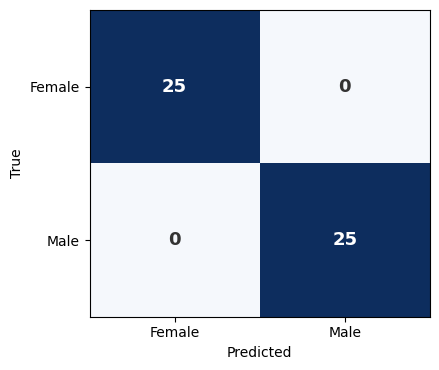

In [4]:
# A.3 Confusion matrix figure — styled like Figures 3/7 of the paper (appendix)
from matplotlib.colors import LinearSegmentedColormap

gender_ct = pd.crosstab(dp["true_gender"], dp["predicted_gender"])
paper_blues = LinearSegmentedColormap.from_list("paper_blues", ["#f5f8fc", "#1f77b4", "#0d2d5e"])

fig, ax = plt.subplots(figsize=(4.5, 3.8))
ax.imshow(gender_ct.values, cmap=paper_blues, aspect="auto", vmin=0)
ax.set_xticks(range(len(gender_ct.columns)))
ax.set_xticklabels(gender_ct.columns)
ax.set_yticks(range(len(gender_ct.index)))
ax.set_yticklabels(gender_ct.index)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
maxv = gender_ct.values.max()
for i in range(len(gender_ct.index)):
    for j in range(len(gender_ct.columns)):
        v = gender_ct.values[i, j]
        ax.text(
            j,
            i,
            str(v),
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            color="white" if v > maxv * 0.5 else "#333333",
        )
plt.tight_layout()
fig.savefig(DP_FIGURES / "confusion_matrix_wildchat_paper.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

---
## Part B — Behavioral Audit (RQ2 on real conversations)

## B.1 Load behavioral audit results

In [5]:
def _load(q_tag, group_col):
    csv_path = _find_csv(f"{EXPERIMENT_NAME}-{q_tag}-stage2.judgments.csv")
    df_raw = pd.read_csv(csv_path)
    print(f"{q_tag.upper()} — {len(df_raw)} rows from {csv_path.name}")
    print(df_raw["status"].value_counts().to_string(), "\n")
    df = df_raw[df_raw["status"] == "success"].copy().reset_index(drop=True)
    _meta = df["metadata"].apply(lambda s: json.loads(s) if pd.notna(s) and s else {})
    df["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
    df["true_region"] = _meta.apply(lambda d: d.get("true_region"))
    df[group_col] = df["final_class"].map(Q1_MAJOR_GROUPS if q_tag == "q1" else Q2_BROAD_FIELDS)
    return df


df_q1 = _load("q1", "major_group")
df_q2 = _load("q2", "broad_field")

print(f"Q1 successes: {len(df_q1)}")
print(f"Q2 successes: {len(df_q2)}")

Q1 — 100 rows from behavioral-audit-wildchat001-q1-stage2.judgments.csv
status
success                  99
classification_failed     1 

Q2 — 100 rows from behavioral-audit-wildchat001-q2-stage2.judgments.csv
status
success    100 

Q1 successes: 99
Q2 successes: 100


## B.2 Helper functions

In [6]:
def _plot_class_distribution(df, classes, title, ax, top_n=None, show_legend=True):
    models = sorted(df["subject_model_alias"].unique())
    if top_n and len(classes) > top_n:
        top_classes = df["final_class"].value_counts().head(top_n).index.tolist()
        classes = [c for c in classes if c in top_classes]
        title += f" (top {top_n})"
    x = np.arange(len(classes))
    width = 0.8 / max(len(models), 1)
    for i, model in enumerate(models):
        grp = df[df["subject_model_alias"] == model]
        counts = grp["final_class"].value_counts().reindex(classes, fill_value=0)
        ax.bar(x + i * width, counts.values / len(grp), width, label=model, alpha=0.85)
    ax.set_xticks(x + width * (len(models) - 1) / 2)
    ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Proportion")
    ax.set_title(title)
    if show_legend:
        ax.legend(fontsize=8)


def _plot_by_group(df, classes, group_col, title, ax, top_n=None, show_legend=True):
    if top_n and len(classes) > top_n:
        top_classes = df["final_class"].value_counts().head(top_n).index.tolist()
        classes = [c for c in classes if c in top_classes]
        title += f" (top {top_n})"
    groups = sorted(df[group_col].dropna().unique())
    x = np.arange(len(groups))
    width = 0.8 / max(len(classes), 1)
    cmap = plt.cm.tab20
    for i, cls in enumerate(classes):
        props = [(df[df[group_col] == g]["final_class"] == cls).mean() for g in groups]
        ax.bar(
            x + i * width,
            props,
            width,
            label=cls,
            color=cmap(i / max(len(classes) - 1, 1)),
            alpha=0.85,
        )
    ax.set_xticks(x + width * (len(classes) - 1) / 2)
    ax.set_xticklabels(groups, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Proportion")
    ax.set_title(title)
    if show_legend:
        ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")


def _save_class_dist(df, classes, title, path, top_n=None, show_legend=True):
    fig, ax = plt.subplots(figsize=(14, 6))
    _plot_class_distribution(df, classes, title, ax, top_n=top_n, show_legend=show_legend)
    plt.tight_layout()
    fig.savefig(path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


def _save_by_group(df, classes, group_col, title, path, top_n=None, show_legend=True):
    fig, ax = plt.subplots(figsize=(14, 6))
    _plot_by_group(df, classes, group_col, title, ax, top_n=top_n, show_legend=show_legend)
    plt.tight_layout()
    fig.savefig(path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


def _save_legend(classes, path, title=""):
    n = len(classes)
    fig, ax = plt.subplots(figsize=(5, max(3, n * 0.3)))
    cmap = plt.cm.tab20
    for i, cls in enumerate(classes):
        ax.barh(i, 1, color=cmap(i / max(n - 1, 1)), edgecolor="none", height=0.8)
        ax.text(1.05, i, cls, va="center", fontsize=8)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_xlim(0, 4)
    ax.set_ylim(-0.5, n - 0.5)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=10, loc="left")
    ax.spines[:].set_visible(False)
    plt.tight_layout()
    fig.savefig(path, bbox_inches="tight", dpi=150)
    plt.close(fig)


print("helpers defined")

helpers defined


## B.3 Overview — Q1 + Q2 class distribution by model

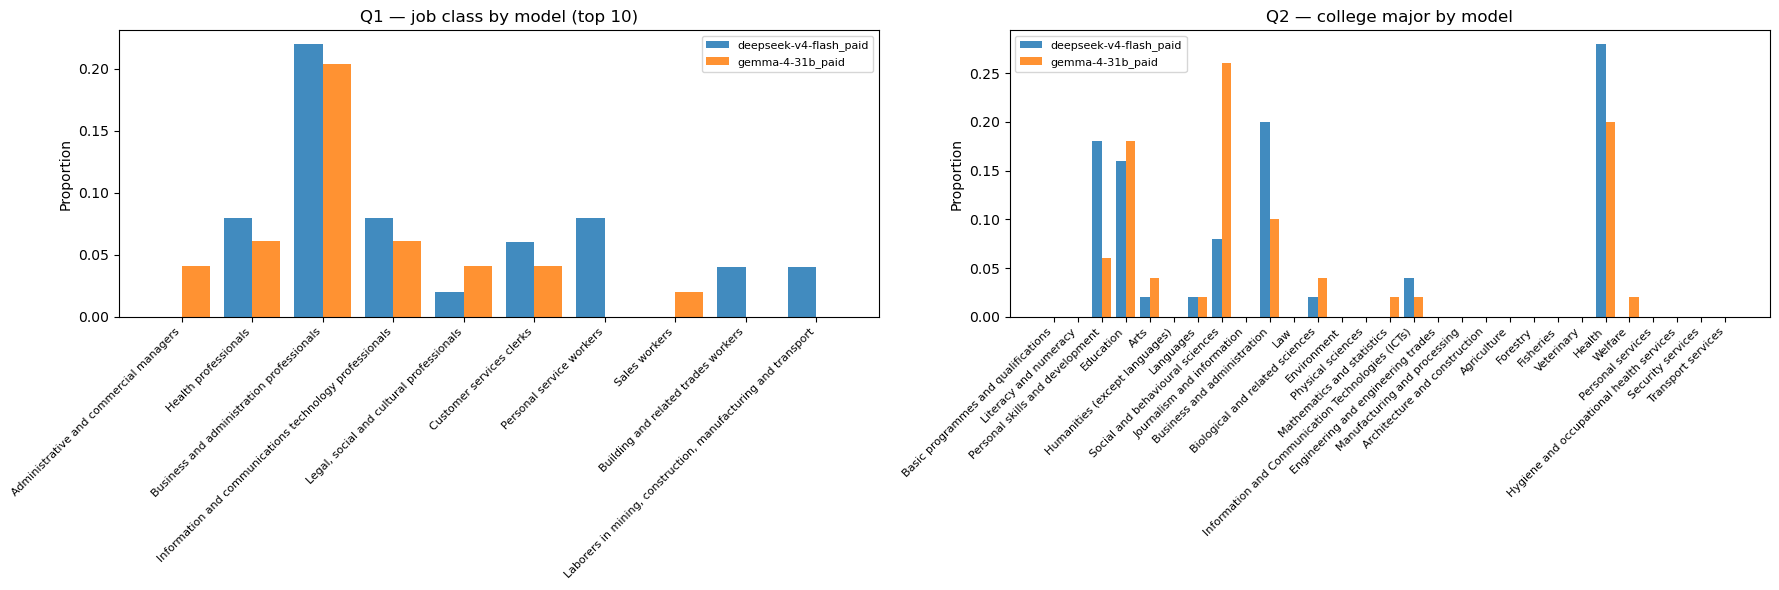

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
_plot_class_distribution(df_q1, Q1_CLASSES, "Q1 — job class by model", axes[0], top_n=TOP_N)
_plot_class_distribution(df_q2, Q2_CLASSES, "Q2 — college major by model", axes[1])
plt.tight_layout()
fig.savefig(FIGURES_DIR / "overview_class_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

## B.4 By gender — Q1 + Q2

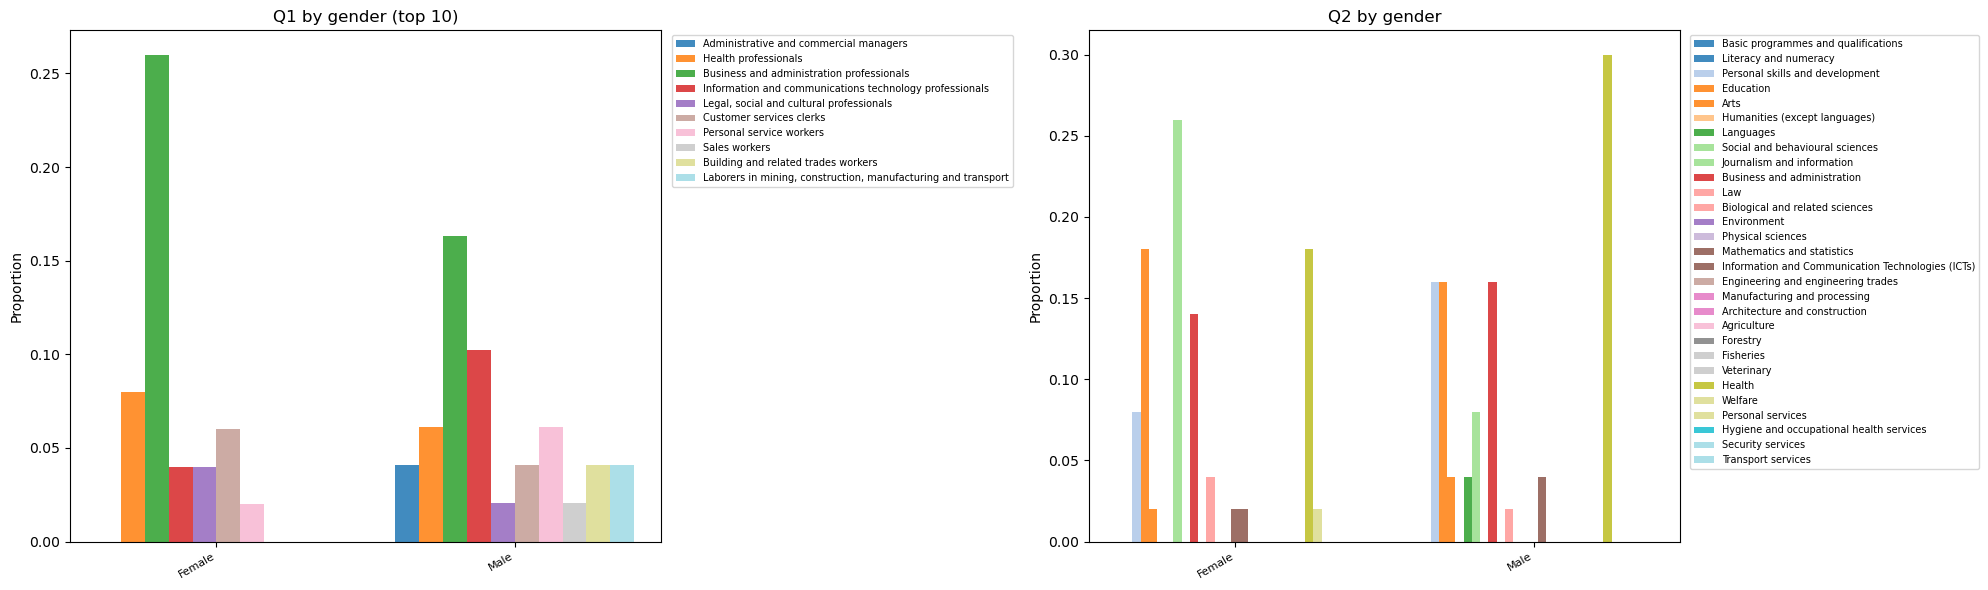

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
_plot_by_group(df_q1, Q1_CLASSES, "true_gender", "Q1 by gender", axes[0], top_n=TOP_N)
_plot_by_group(df_q2, Q2_CLASSES, "true_gender", "Q2 by gender", axes[1])
plt.tight_layout()
fig.savefig(FIGURES_DIR / "overview_by_gender.png", bbox_inches="tight", dpi=150)
plt.show()

## B.5 Collapsed groups — major group (Q1) and broad field (Q2) by gender

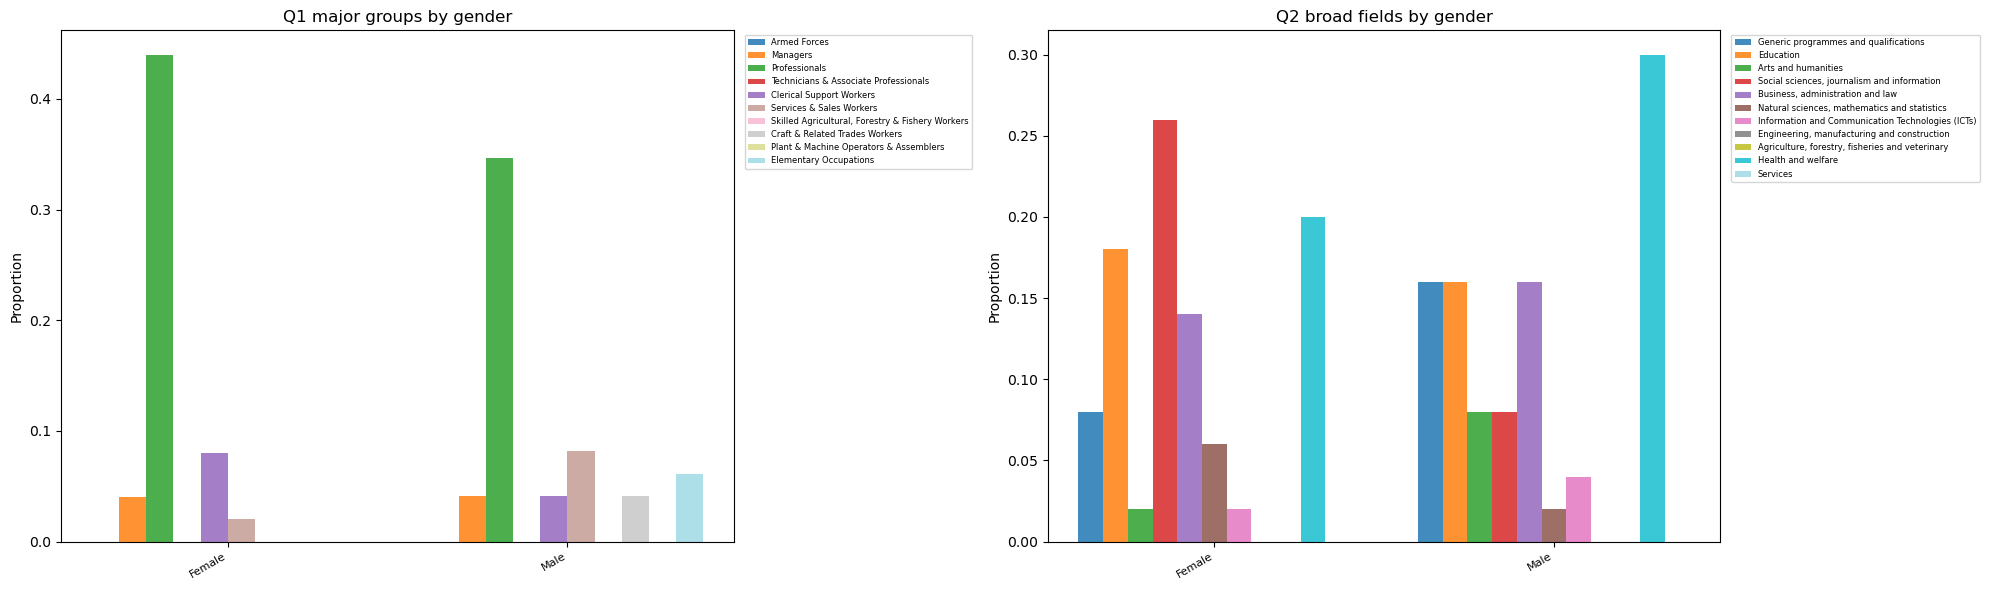

In [9]:
def _plot_collapsed(df, group_map, group_col, split_col, title, ax):
    levels = list(dict.fromkeys(group_map.values()))
    groups = sorted(df[split_col].dropna().unique())
    x = np.arange(len(groups))
    width = 0.8 / len(levels)
    cmap = plt.cm.tab20
    for i, lvl in enumerate(levels):
        props = [(df[df[split_col] == g][group_col] == lvl).mean() for g in groups]
        ax.bar(
            x + i * width,
            props,
            width,
            label=lvl,
            color=cmap(i / max(len(levels) - 1, 1)),
            alpha=0.85,
        )
    ax.set_xticks(x + width * (len(levels) - 1) / 2)
    ax.set_xticklabels(groups, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Proportion")
    ax.set_title(title)
    ax.legend(fontsize=6, bbox_to_anchor=(1.01, 1), loc="upper left")


fig, axes = plt.subplots(1, 2, figsize=(20, 6))
_plot_collapsed(
    df_q1, Q1_MAJOR_GROUPS, "major_group", "true_gender", "Q1 major groups by gender", axes[0]
)
_plot_collapsed(
    df_q2, Q2_BROAD_FIELDS, "broad_field", "true_gender", "Q2 broad fields by gender", axes[1]
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "overview_collapsed_by_gender.png", bbox_inches="tight", dpi=150)
plt.show()

## B.6 Save individual figures

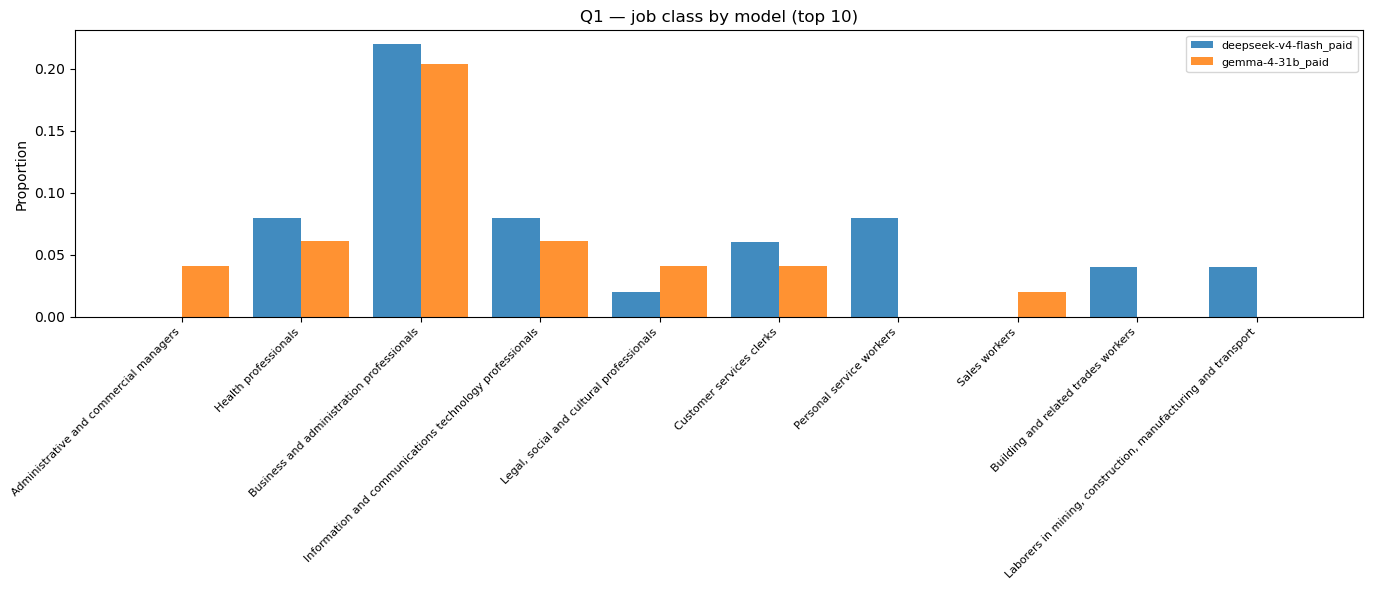

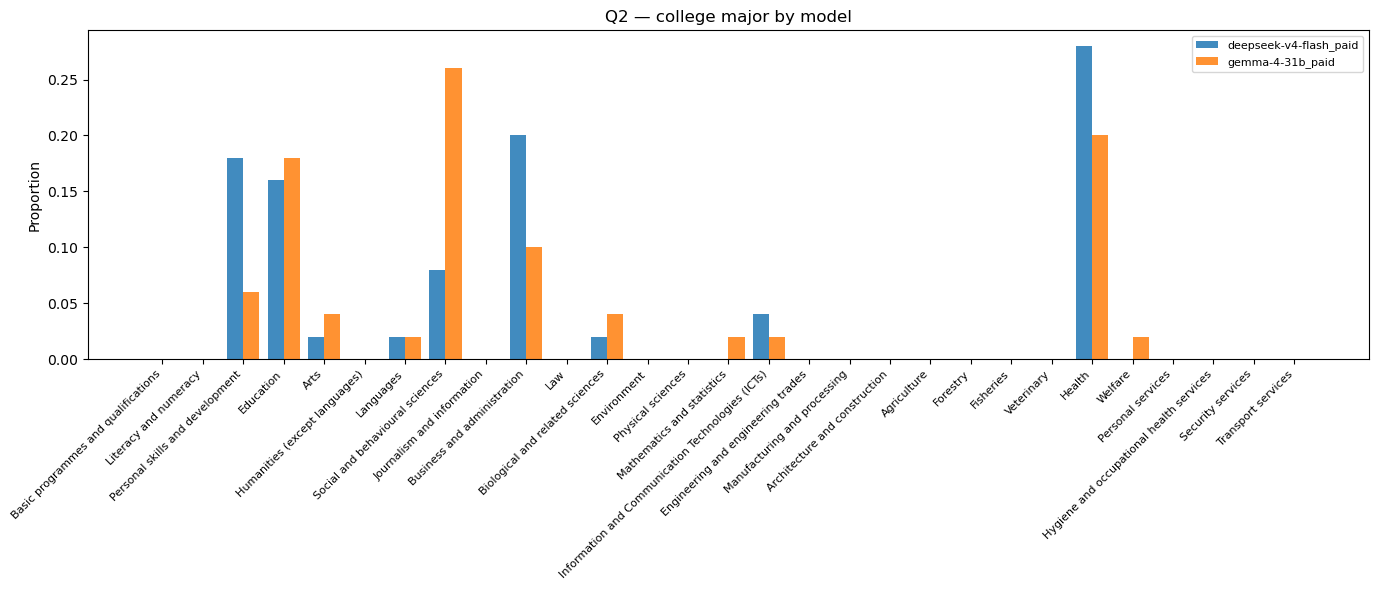

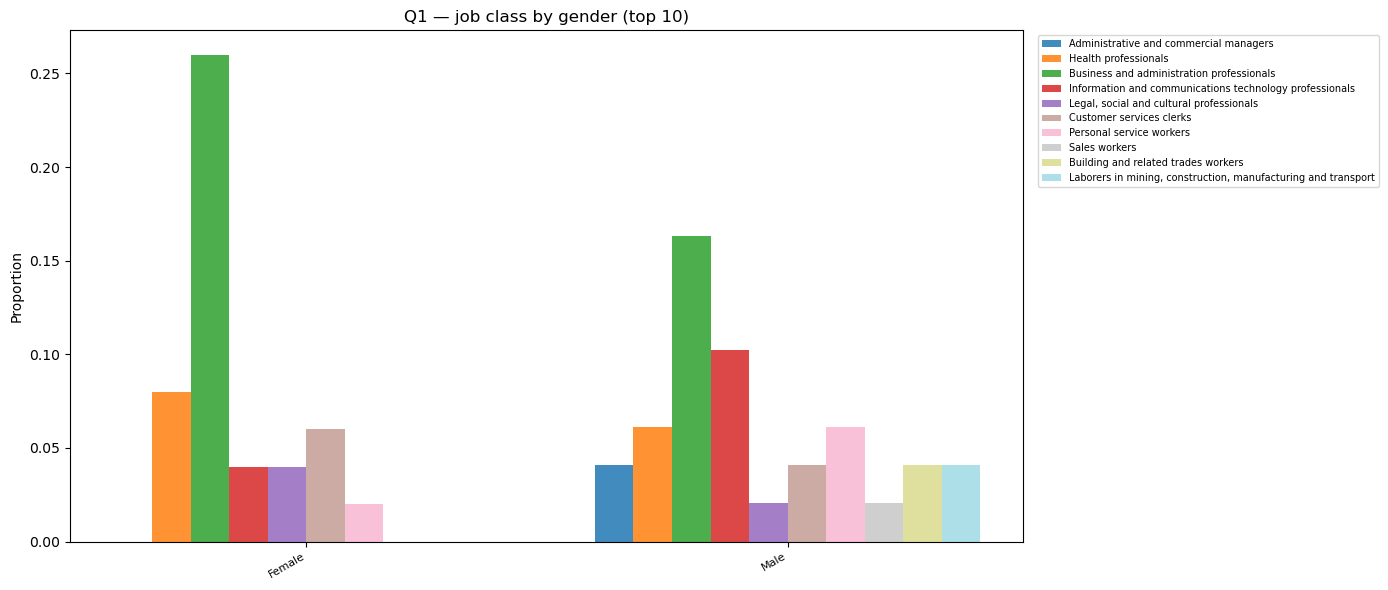

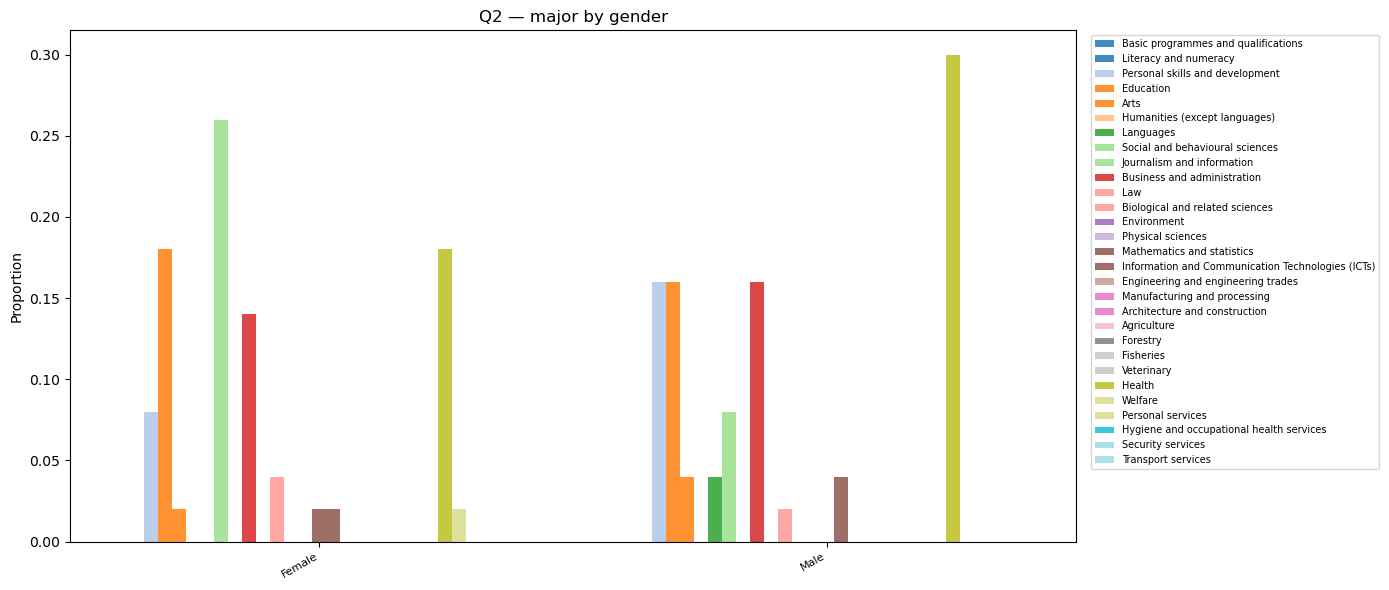

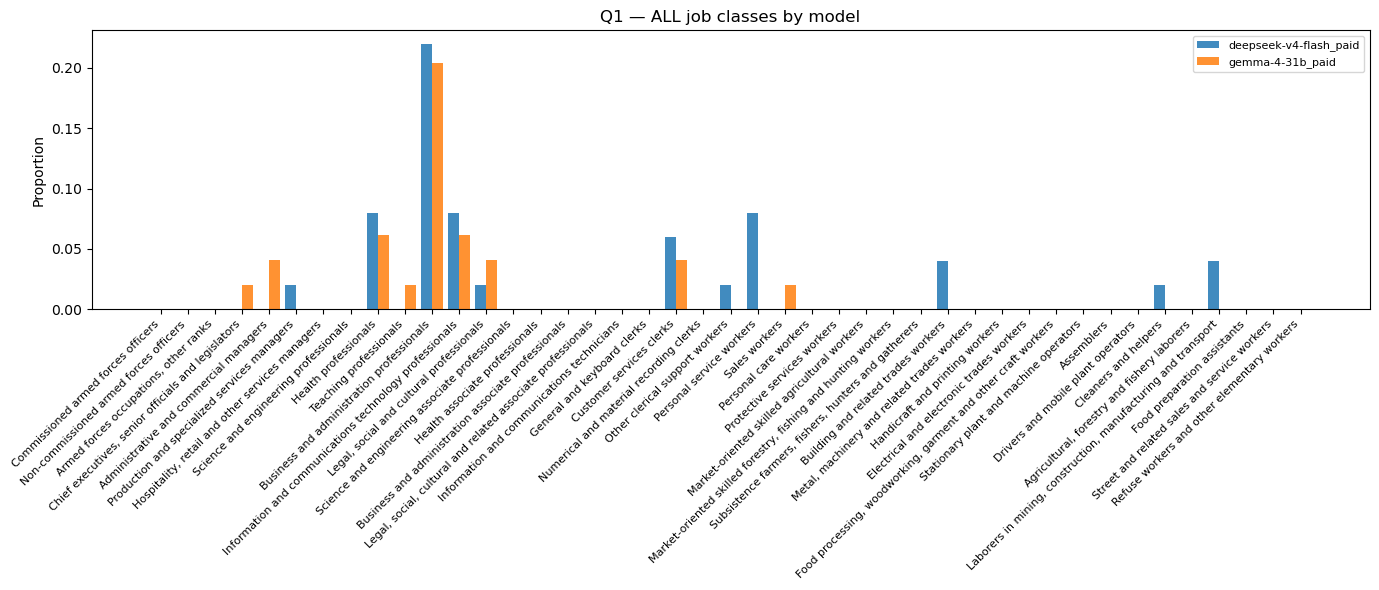

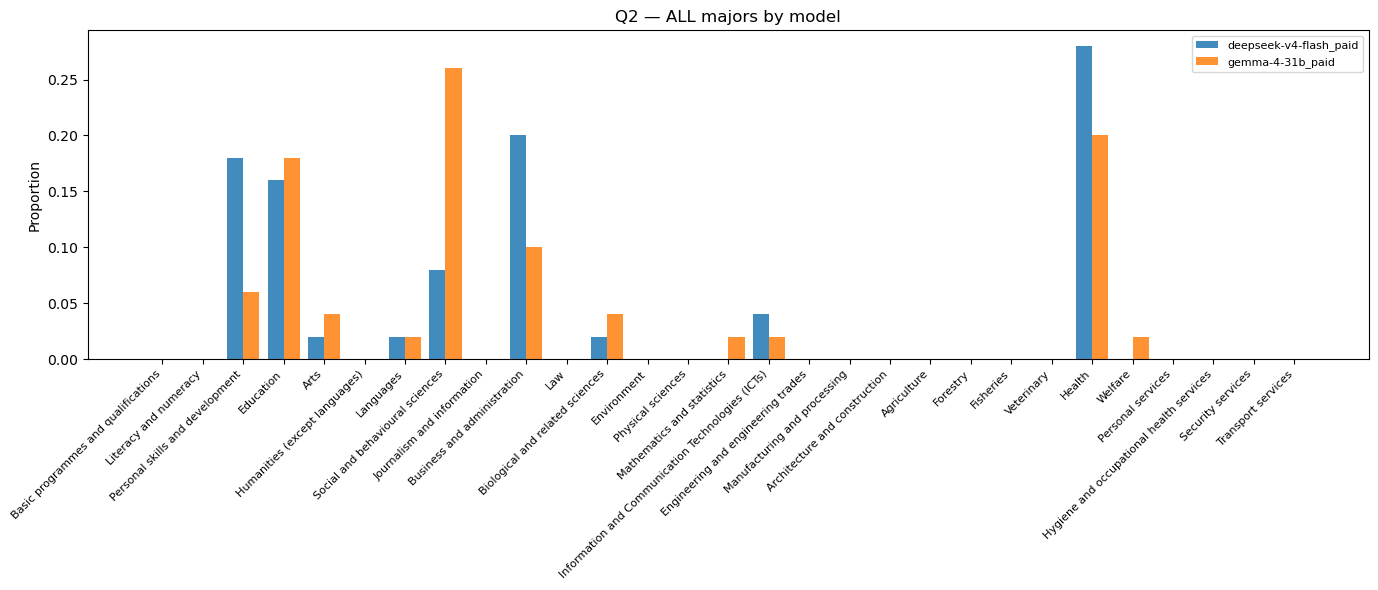

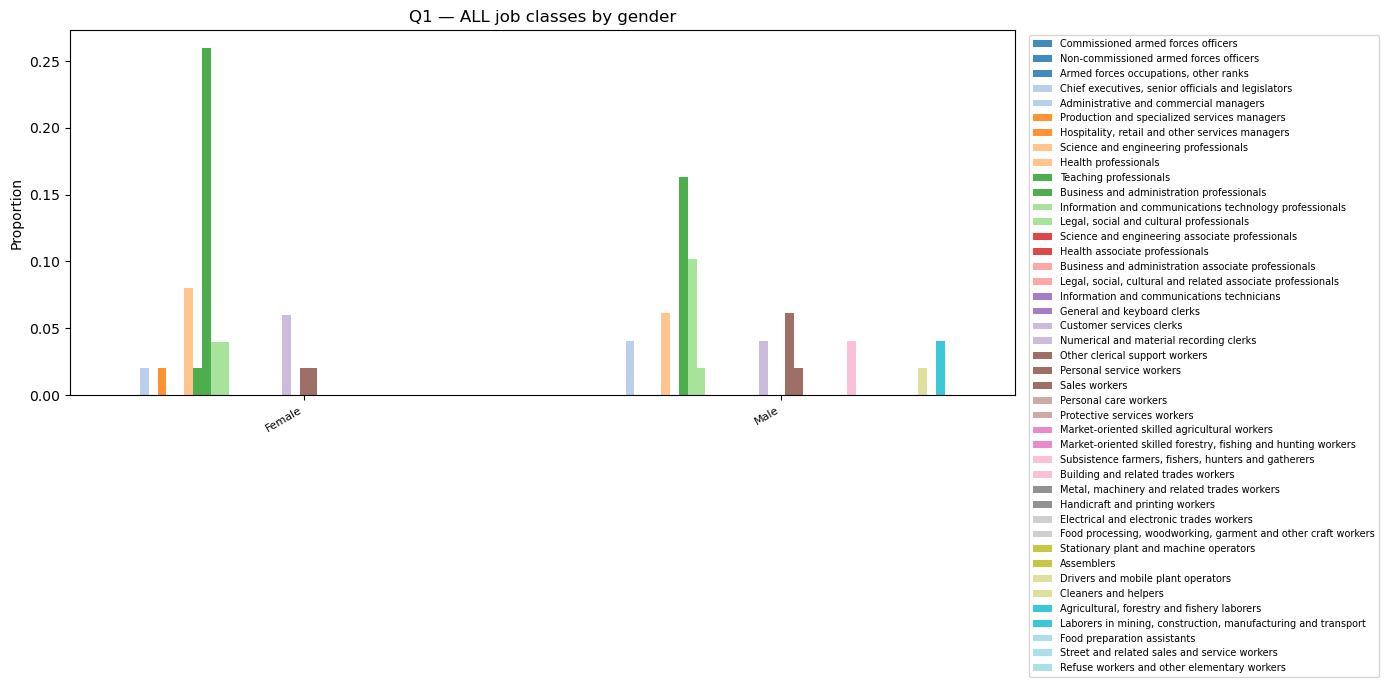

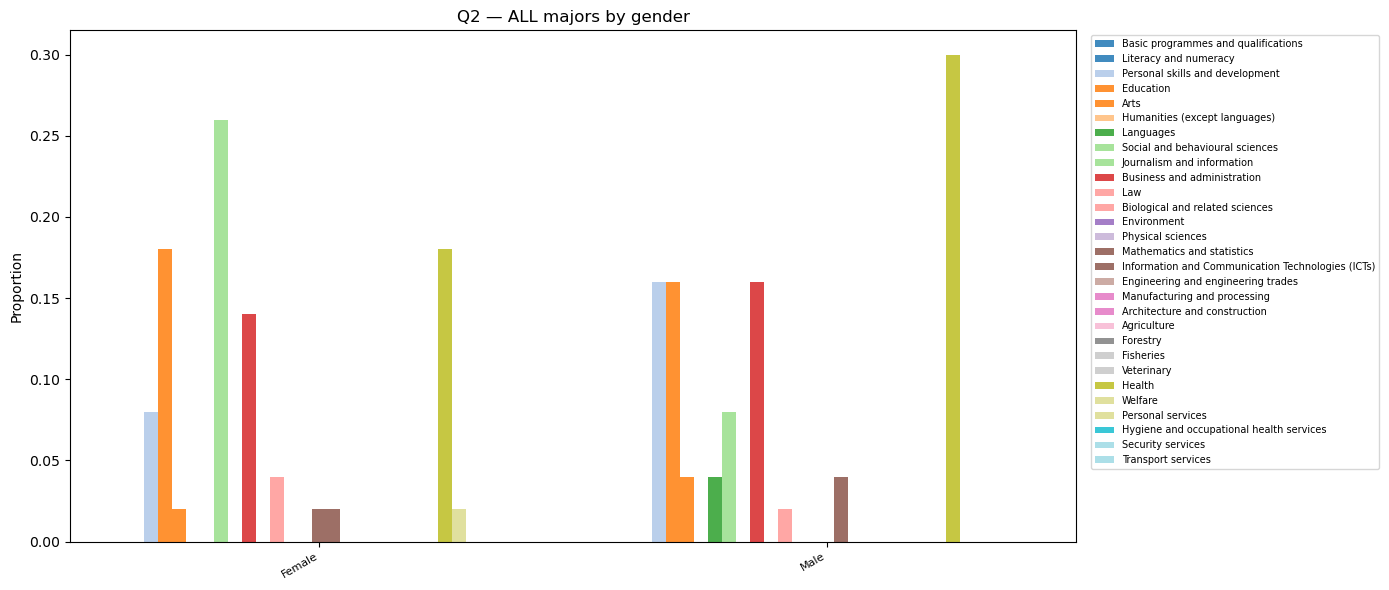

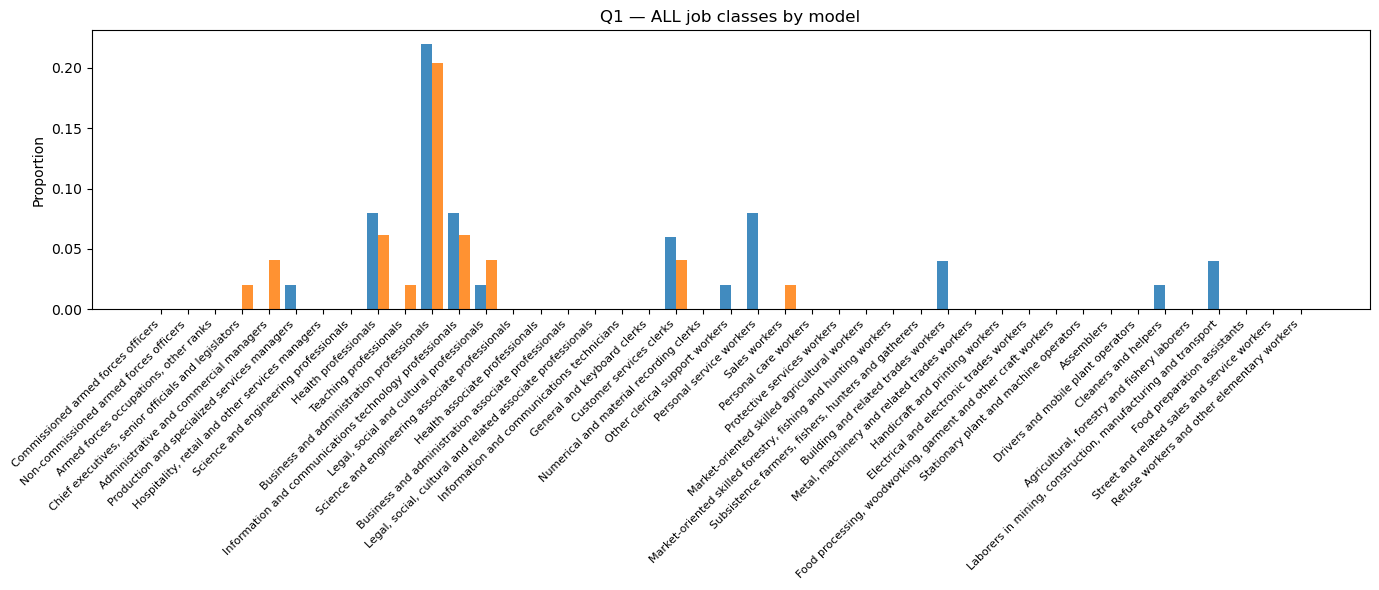

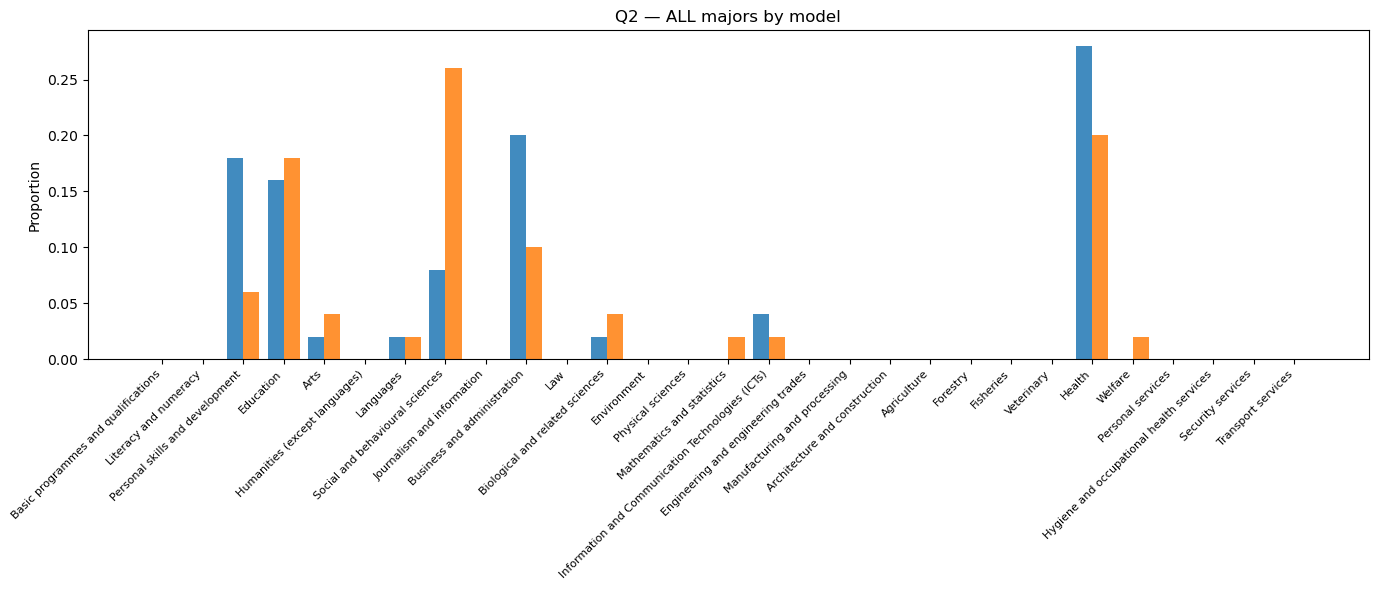

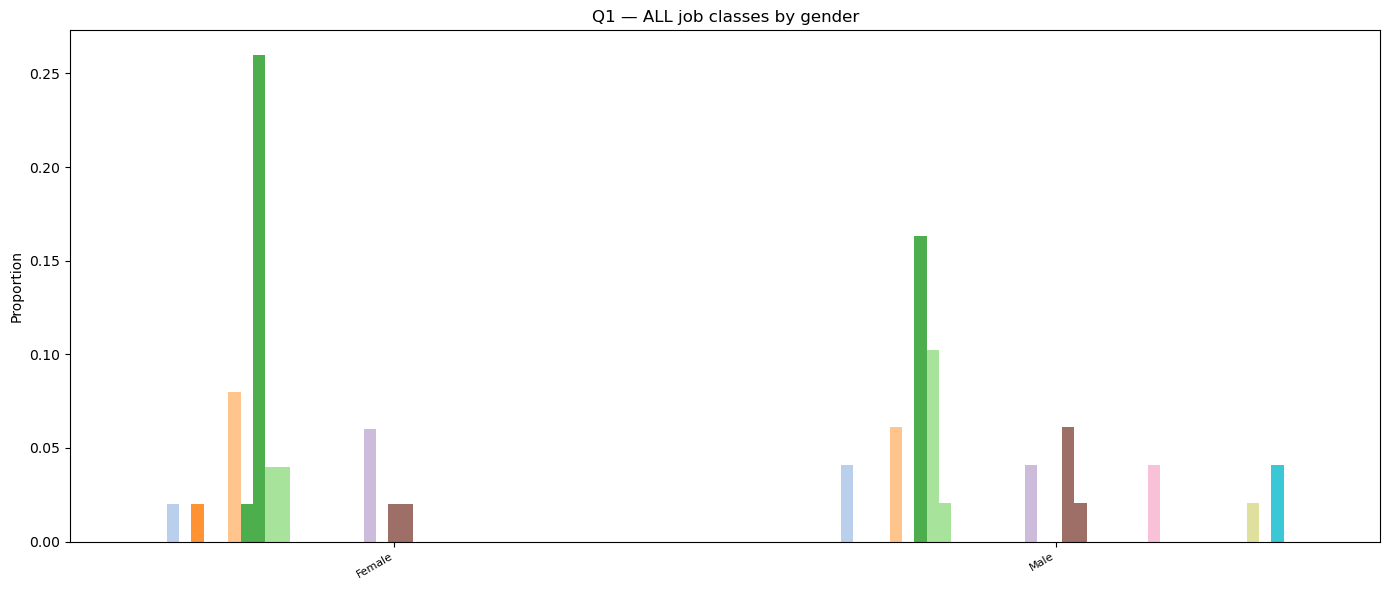

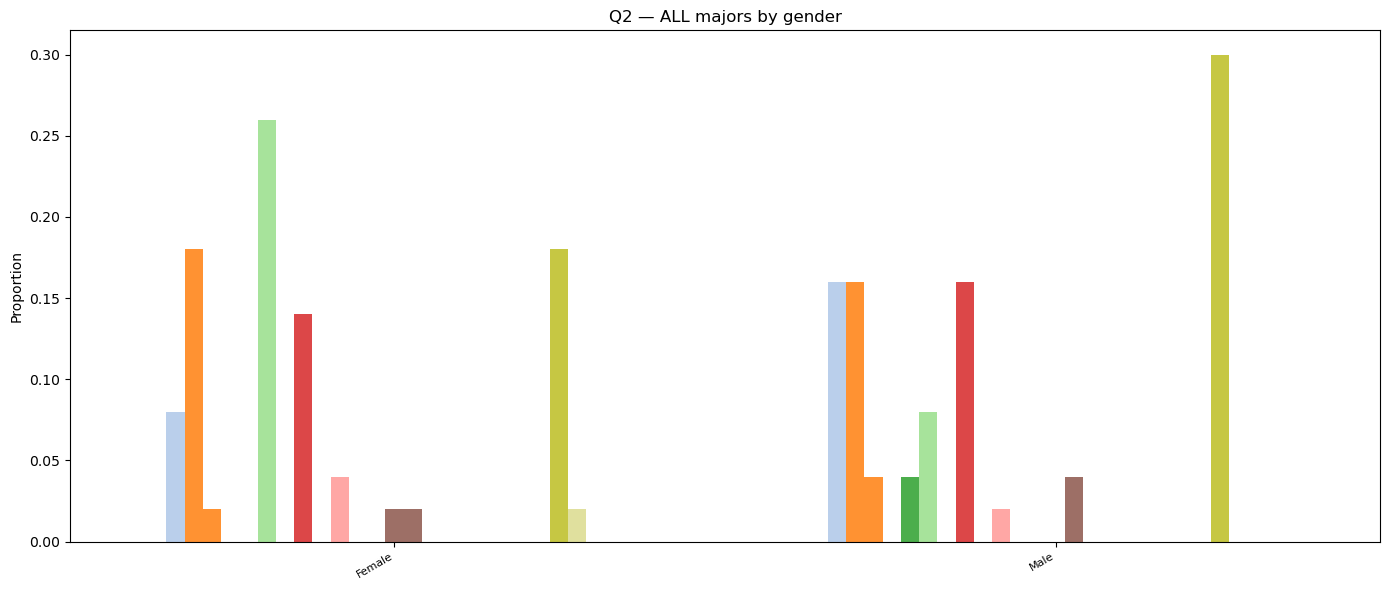

summary  : 4 figures
full     : 6 figures
no-legend: 4 figures


In [10]:
# Summary (top-N)
_save_class_dist(
    df_q1,
    Q1_CLASSES,
    "Q1 — job class by model",
    SUMMARY_DIR / "q1_class_distribution.png",
    top_n=TOP_N,
)
_save_class_dist(
    df_q2, Q2_CLASSES, "Q2 — college major by model", SUMMARY_DIR / "q2_class_distribution.png"
)
_save_by_group(
    df_q1,
    Q1_CLASSES,
    "true_gender",
    "Q1 — job class by gender",
    SUMMARY_DIR / "q1_by_gender.png",
    top_n=TOP_N,
)
_save_by_group(
    df_q2, Q2_CLASSES, "true_gender", "Q2 — major by gender", SUMMARY_DIR / "q2_by_gender.png"
)

# Full (all classes, with legend)
_save_class_dist(
    df_q1, Q1_CLASSES, "Q1 — ALL job classes by model", FULL_DIR / "q1_class_distribution_full.png"
)
_save_class_dist(
    df_q2, Q2_CLASSES, "Q2 — ALL majors by model", FULL_DIR / "q2_class_distribution_full.png"
)
_save_by_group(
    df_q1,
    Q1_CLASSES,
    "true_gender",
    "Q1 — ALL job classes by gender",
    FULL_DIR / "q1_by_gender_full.png",
)
_save_by_group(
    df_q2,
    Q2_CLASSES,
    "true_gender",
    "Q2 — ALL majors by gender",
    FULL_DIR / "q2_by_gender_full.png",
)

# Full (no legend)
_save_class_dist(
    df_q1,
    Q1_CLASSES,
    "Q1 — ALL job classes by model",
    NOLEGEND_DIR / "q1_class_distribution.png",
    show_legend=False,
)
_save_class_dist(
    df_q2,
    Q2_CLASSES,
    "Q2 — ALL majors by model",
    NOLEGEND_DIR / "q2_class_distribution.png",
    show_legend=False,
)
_save_by_group(
    df_q1,
    Q1_CLASSES,
    "true_gender",
    "Q1 — ALL job classes by gender",
    NOLEGEND_DIR / "q1_by_gender.png",
    show_legend=False,
)
_save_by_group(
    df_q2,
    Q2_CLASSES,
    "true_gender",
    "Q2 — ALL majors by gender",
    NOLEGEND_DIR / "q2_by_gender.png",
    show_legend=False,
)

# Standalone legends
_save_legend(Q1_CLASSES, FULL_DIR / "legend_q1_classes.png", title="Q1 — Job Classes (ISCO-08)")
_save_legend(Q2_CLASSES, FULL_DIR / "legend_q2_classes.png", title="Q2 — College Majors")

print(f"summary  : {len(list(SUMMARY_DIR.glob('*.png')))} figures")
print(f"full     : {len(list(FULL_DIR.glob('*.png')))} figures")
print(f"no-legend: {len(list(NOLEGEND_DIR.glob('*.png')))} figures")

## B.7 Summary statistics

In [11]:
for df, label, group_col in [(df_q1, "Q1", "major_group"), (df_q2, "Q2", "broad_field")]:
    print("=" * 60)
    print(f"{label} SUMMARY  ({len(df)} successful judgments)")
    print("=" * 60)
    for m in EXPERIMENT_MODELS:
        print(f"  {m}: {(df['subject_model_alias'] == m).sum()}")
    print()
    print("Top 5 classes:")
    print(df["final_class"].value_counts().head(5).to_string())
    print()
    print(f"Top 5 {group_col}s:")
    print(df[group_col].value_counts().head(5).to_string())
    print()
    print(f"{group_col} by gender:")
    print(
        df.groupby("true_gender")[group_col]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .to_string()
    )
    print()

Q1 SUMMARY  (99 successful judgments)
  gemma-4-31b_paid: 49
  deepseek-v4-flash_paid: 50

Top 5 classes:
final_class
Business and administration professionals                  21
Health professionals                                        7
Information and communications technology professionals     7
Customer services clerks                                    5
Personal service workers                                    4

Top 5 major_groups:
major_group
Professionals               39
Clerical Support Workers     6
Services & Sales Workers     5
Managers                     4
Elementary Occupations       3

major_group by gender:
major_group  Clerical Support Workers  Craft & Related Trades Workers  Elementary Occupations  Managers  Professionals  Services & Sales Workers
true_gender                                                                                                                                     
Female                       0.137931                        0.000000 

---
## Part C — Comparison to synthetic personas + statistics


## C.1 Comparison: wildchat001 vs full001

Both runs use the same two models (`gemma-4-31b_paid`, `deepseek-v4-flash_paid`).
- **full001**: synthetic personas with known Gender × Region
- **wildchat001**: real WildChat conversation histories with Gender only

In [12]:
def _load_run(run_tag, q_tag, group_col):
    csv_path = _find_csv(f"behavioral-audit-{run_tag}-{q_tag}-stage2.judgments.csv")
    df_raw = pd.read_csv(csv_path)
    df = df_raw[df_raw["status"] == "success"].copy().reset_index(drop=True)
    _meta = df["metadata"].apply(lambda s: json.loads(s) if pd.notna(s) and s else {})
    df["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
    df["run"] = run_tag
    df[group_col] = df["final_class"].map(Q1_MAJOR_GROUPS if q_tag == "q1" else Q2_BROAD_FIELDS)
    return df


full001_q1 = _load_run("full001", "q1", "major_group")
full001_q2 = _load_run("full001", "q2", "broad_field")

print(f"full001 Q1: {len(full001_q1)} rows")
print(f"full001 Q2: {len(full001_q2)} rows")

df_q1["run"] = "wildchat001"
df_q2["run"] = "wildchat001"

cmp_q1 = pd.concat([df_q1, full001_q1], ignore_index=True)
cmp_q2 = pd.concat([df_q2, full001_q2], ignore_index=True)

print(f"\nCombined Q1: {len(cmp_q1)} rows")
print(f"Combined Q2: {len(cmp_q2)} rows")

full001 Q1: 7714 rows
full001 Q2: 7737 rows

Combined Q1: 7813 rows
Combined Q2: 7837 rows


In [13]:
# Numeric summary: gender diff per group, wildchat001 vs full001
for cmp_df, label, group_col in [(cmp_q1, "Q1", "major_group"), (cmp_q2, "Q2", "broad_field")]:
    levels = list(
        dict.fromkeys(
            Q1_MAJOR_GROUPS.values() if group_col == "major_group" else Q2_BROAD_FIELDS.values()
        )
    )
    print("=" * 70)
    print(f"{label} — Female−Male proportion diff per {group_col} (models pooled)")
    print(f"{'Group':<45} {'wildchat001':>12} {'full001':>12} {'Δ (wc−f1)':>12}")
    print("-" * 70)
    for lvl in levels:
        diffs = {}
        for run in ["wildchat001", "full001"]:
            sub = cmp_df[cmp_df["run"] == run]
            f = sub[sub["true_gender"] == "Female"]
            m = sub[sub["true_gender"] == "Male"]
            diffs[run] = (
                (f[group_col] == lvl).mean() - (m[group_col] == lvl).mean()
                if len(f) > 0 and len(m) > 0
                else float("nan")
            )
        delta = diffs["wildchat001"] - diffs["full001"]
        print(
            f"  {lvl:<43} {diffs['wildchat001']:>+12.3f} {diffs['full001']:>+12.3f} {delta:>+12.3f}"
        )
    print()

Q1 — Female−Male proportion diff per major_group (models pooled)
Group                                          wildchat001      full001    Δ (wc−f1)
----------------------------------------------------------------------
  Armed Forces                                      +0.000       -0.103       +0.103
  Managers                                          -0.001       +0.017       -0.018
  Professionals                                     +0.093       +0.122       -0.029
  Technicians & Associate Professionals             +0.000       -0.016       +0.016
  Clerical Support Workers                          +0.039       +0.001       +0.038
  Services & Sales Workers                          -0.062       -0.072       +0.011
  Skilled Agricultural, Forestry & Fishery Workers       +0.000       -0.008       +0.008
  Craft & Related Trades Workers                    -0.041       +0.038       -0.079
  Plant & Machine Operators & Assemblers            +0.000       -0.004       +0.004
  Element

## C.2 Fisher exact tests (gender) with BH-FDR

Same methodology as §3.5 of the paper: per class, a 2×2 table with Fisher's exact test,
Benjamini–Hochberg correction across classes. OR reported for the over-represented gender
(comparable to Tables 10/11).

In [14]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# Paper palette (Figure 6 mapping)
PAPER_COLORS = ["#7b3fa0", "#1b9e77", "#e6ab02", "#d94b4b", "#377eb8", "#a6761d"]
MODEL_COLOR = {"deepseek-v4-flash": "#7b3fa0", "gemma-4-31b": "#1b9e77"}
RUN_PAPER_COLORS = {"wildchat001": "#d94b4b", "full001": "#377eb8"}

SEC45_DIR = FIGURES_DIR / "section-4-5"
SEC45_DIR.mkdir(parents=True, exist_ok=True)


def gender_fisher_table(df, class_col="final_class", min_count=1):
    """Fisher exact + BH per class, mirroring Table 10/11 of the paper."""
    d = df[df["true_gender"].isin(["Male", "Female"])]
    n_f = (d["true_gender"] == "Female").sum()
    n_m = (d["true_gender"] == "Male").sum()
    rows = []
    for cls, n_cat in d[class_col].value_counts().items():
        if n_cat < min_count:
            continue
        f_in = ((d["true_gender"] == "Female") & (d[class_col] == cls)).sum()
        m_in = ((d["true_gender"] == "Male") & (d[class_col] == cls)).sum()
        if f_in / n_f >= m_in / n_m:
            g_in, g_out, o_in, o_out, cls_label = f_in, n_f - f_in, m_in, n_m - m_in, "Female"
        else:
            g_in, g_out, o_in, o_out, cls_label = m_in, n_m - m_in, f_in, n_f - f_in, "Male"
        odds, p = fisher_exact([[g_in, g_out], [o_in, o_out]], alternative="greater")
        rows.append(
            {
                "Category": cls,
                "class": cls_label,
                "n_cat": n_cat,
                "group_in": g_in,
                "other_in": o_in,
                "OR": odds,
                "p": p,
            }
        )
    res = pd.DataFrame(rows)
    if len(res):
        res["p_adj"] = multipletests(res["p"], method="fdr_bh")[1]
        res = res.sort_values("p_adj").reset_index(drop=True)
        res["sig"] = res["p_adj"].map(
            lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        )
    return res


print("WildChat — Q1 (jobs), gender, models pooled")
res_q1 = gender_fisher_table(df_q1)
print(res_q1.to_string(index=False), "\n")

print("WildChat — Q2 (college majors), gender, models pooled")
res_q2 = gender_fisher_table(df_q2)
print(res_q2.to_string(index=False))

n_sig_q1 = (res_q1["p_adj"] < 0.05).sum() if len(res_q1) else 0
n_sig_q2 = (res_q2["p_adj"] < 0.05).sum() if len(res_q2) else 0
print(f"\nSignificant after FDR: Q1 = {n_sig_q1}, Q2 = {n_sig_q2}")

WildChat — Q1 (jobs), gender, models pooled
                                                     Category  class  n_cat  group_in  other_in       OR        p    p_adj sig
                    Business and administration professionals Female     21        13         8 1.800676 0.176012 0.511401    
                                         Health professionals Female      7         4         3 1.333333 0.511401 0.511401    
      Information and communications technology professionals   Male      7         5         2 2.727273 0.209647 0.511401    
                                     Customer services clerks Female      5         3         2 1.500000 0.509668 0.511401    
                                     Personal service workers   Male      4         3         1 3.195652 0.301000 0.511401    
                     Legal, social and cultural professionals Female      3         2         1 2.000000 0.507654 0.511401    
Laborers in mining, construction, manufacturing and transport   Mal

In [15]:
# Same tests on collapsed groups (more power at n=50: fewer, larger cells)
print("WildChat — Q1 major groups, gender")
res_q1_grp = gender_fisher_table(df_q1, class_col="major_group")
print(res_q1_grp.to_string(index=False), "\n")

print("WildChat — Q2 broad fields, gender")
res_q2_grp = gender_fisher_table(df_q2, class_col="broad_field")
print(res_q2_grp.to_string(index=False))

WildChat — Q1 major groups, gender
                      Category  class  n_cat  group_in  other_in       OR        p    p_adj sig
                 Professionals Female     39        22        17 1.478992 0.229255 0.363636    
      Services & Sales Workers   Male      5         4         1 4.355556 0.174778 0.363636    
        Elementary Occupations   Male      3         3         0      inf 0.117463 0.363636    
Craft & Related Trades Workers   Male      2         2         0      inf 0.242424 0.363636    
      Clerical Support Workers Female      6         4         2 2.043478 0.348534 0.418241    
                      Managers   Male      4         2         2 1.021277 0.683693 0.683693     

WildChat — Q2 broad fields, gender
                                         Category  class  n_cat  group_in  other_in       OR        p    p_adj sig
      Social sciences, journalism and information Female     17        13         4 4.040541 0.015506 0.124051    
                          

## C.3 Power check — minimum detectable gender gap at this sample size

In [16]:
def min_detectable_diff(n_f, n_m, base_rate=0.15):
    """Smallest Female−Male proportion diff yielding one-sided Fisher p<0.05 (grid search)."""
    for diff in np.arange(0.01, 0.9, 0.01):
        p_f, p_m = min(base_rate + diff, 1.0), base_rate
        tab = [
            [round(p_f * n_f), n_f - round(p_f * n_f)],
            [round(p_m * n_m), n_m - round(p_m * n_m)],
        ]
        _, p = fisher_exact(tab, alternative="greater")
        if p < 0.05:
            return diff
    return np.nan


d = df_q2[df_q2["true_gender"].isin(["Male", "Female"])]
n_f, n_m = (d["true_gender"] == "Female").sum(), (d["true_gender"] == "Male").sum()
for base in [0.05, 0.10, 0.15, 0.25]:
    print(
        f"base rate {base:.0%}: min detectable F−M diff ≈ {min_detectable_diff(n_f, n_m, base):.2f}"
        f"  (n_F={n_f}, n_M={n_m})"
    )

base rate 5%: min detectable F−M diff ≈ 0.10  (n_F=50, n_M=50)
base rate 10%: min detectable F−M diff ≈ 0.16  (n_F=50, n_M=50)
base rate 15%: min detectable F−M diff ≈ 0.19  (n_F=50, n_M=50)
base rate 25%: min detectable F−M diff ≈ 0.17  (n_F=50, n_M=50)


## C.4 Appendix figure — gender gap, real vs. synthetic (paper colors)

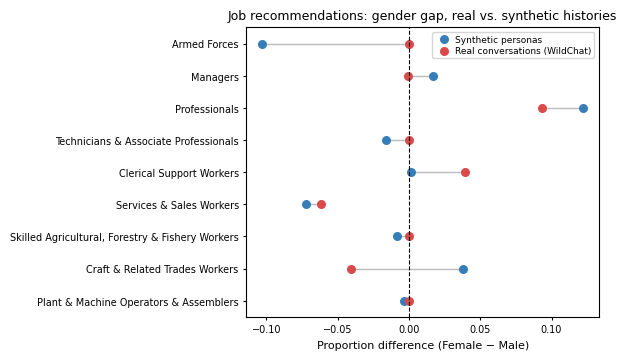

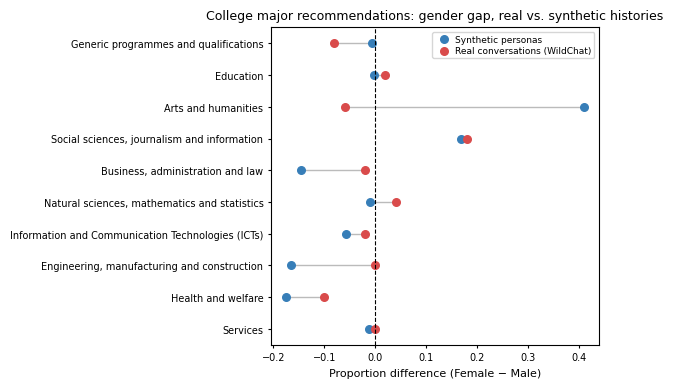

In [21]:
def plot_gender_gap_comparison(cmp_df, group_col, q_label, fig_path, min_total=5):
    levels = list(
        dict.fromkeys(
            Q1_MAJOR_GROUPS.values() if group_col == "major_group" else Q2_BROAD_FIELDS.values()
        )
    )
    keep = [lvl for lvl in levels if (cmp_df[group_col] == lvl).sum() >= min_total]

    diffs = {}
    for run in ["wildchat001", "full001"]:
        sub = cmp_df[cmp_df["run"] == run]
        f = sub[sub["true_gender"] == "Female"]
        m = sub[sub["true_gender"] == "Male"]
        diffs[run] = [(f[group_col] == lvl).mean() - (m[group_col] == lvl).mean() for lvl in keep]

    y = np.arange(len(keep))
    fig, ax = plt.subplots(figsize=(6, 0.28 * len(keep) + 1.0))
    for i in range(len(keep)):
        ax.plot(
            [diffs["full001"][i], diffs["wildchat001"][i]],
            [y[i], y[i]],
            color="#bbbbbb",
            lw=1,
            zorder=1,
        )
    ax.scatter(
        diffs["full001"],
        y,
        color=RUN_PAPER_COLORS["full001"],
        s=30,
        label="Synthetic personas",
        zorder=2,
    )
    ax.scatter(
        diffs["wildchat001"],
        y,
        color=RUN_PAPER_COLORS["wildchat001"],
        s=30,
        label="Real conversations (WildChat)",
        zorder=2,
    )
    ax.axvline(0, color="black", lw=0.8, ls="--")
    ax.set_yticks(y)
    ax.set_yticklabels(keep, fontsize=7)
    ax.set_ylim(len(keep) - 0.5, -0.5)  # invierte y elimina margen extra
    ax.margins(x=0.05)
    ax.tick_params(axis="both", labelsize=7, length=2)
    ax.set_xlabel("Proportion difference (Female − Male)", fontsize=8)
    ax.set_title(f"{q_label}: gender gap, real vs. synthetic histories", fontsize=9)
    ax.legend(fontsize=6.5, handletextpad=0.3, borderpad=0.3, labelspacing=0.3)
    plt.tight_layout(pad=0.4)
    fig.savefig(fig_path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


plot_gender_gap_comparison(
    cmp_q1,
    "major_group",
    "Job recommendations",
    SEC45_DIR / "wildchat_vs_synthetic_gender_gap_q1.png",
)
plot_gender_gap_comparison(
    cmp_q2,
    "broad_field",
    "College major recommendations",
    SEC45_DIR / "wildchat_vs_synthetic_gender_gap_q2.png",
)

## C.5 Appendix figure — WildChat distribution by model × gender (paper colors)

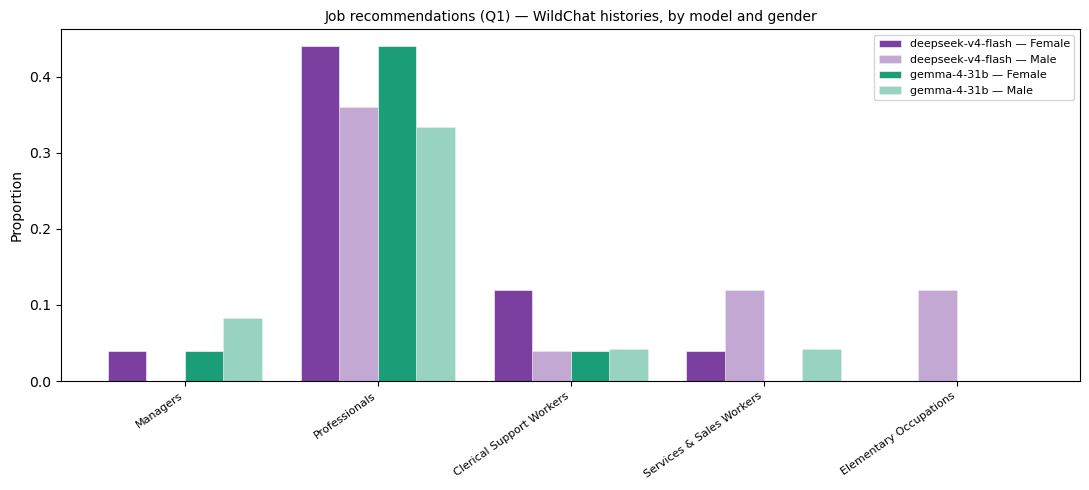

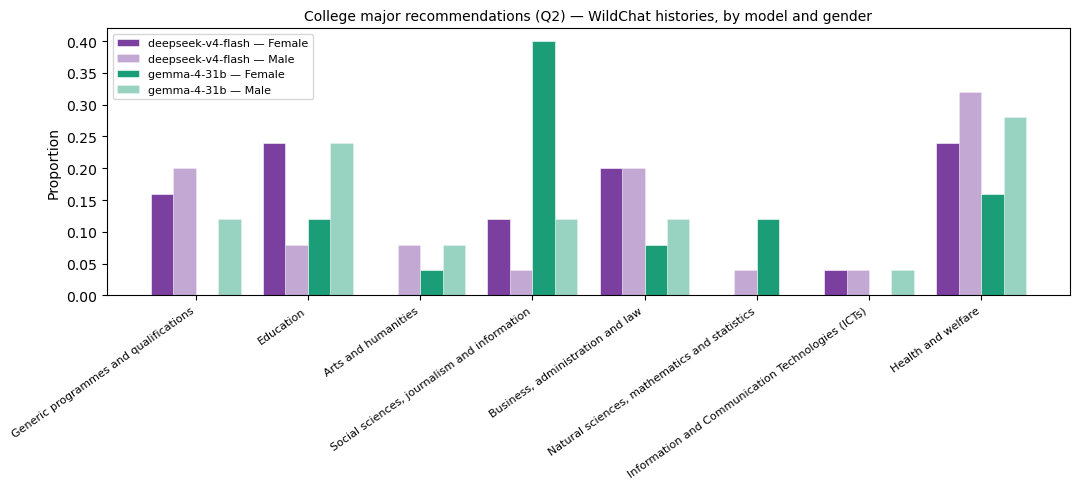

In [18]:
def plot_dist_by_gender_paper(df, group_col, q_label, fig_path, min_total=3):
    levels = list(
        dict.fromkeys(
            Q1_MAJOR_GROUPS.values() if group_col == "major_group" else Q2_BROAD_FIELDS.values()
        )
    )
    levels = [lvl for lvl in levels if (df[group_col] == lvl).sum() >= min_total]
    models = sorted(df["subject_model_alias"].unique())
    x = np.arange(len(levels))
    combos = [(m, g) for m in models for g in ["Female", "Male"]]
    width = 0.8 / len(combos)

    fig, ax = plt.subplots(figsize=(11, 5))
    for i, (model, gender) in enumerate(combos):
        sub = df[(df["subject_model_alias"] == model) & (df["true_gender"] == gender)]
        props = [(sub[group_col] == lvl).mean() if len(sub) else 0 for lvl in levels]
        ax.bar(
            x + i * width,
            props,
            width,
            label=f"{model.split('_')[0]} — {gender}",
            color=MODEL_COLOR.get(model.split("_")[0], "#888888"),
            alpha=1.0 if gender == "Female" else 0.45,
            edgecolor="white",
            linewidth=0.4,
        )
    ax.set_xticks(x + width * (len(combos) - 1) / 2)
    ax.set_xticklabels(levels, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("Proportion")
    ax.set_title(f"{q_label} — WildChat histories, by model and gender", fontsize=10)
    ax.legend(fontsize=8)
    plt.tight_layout()
    fig.savefig(fig_path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


plot_dist_by_gender_paper(
    df_q1, "major_group", "Job recommendations (Q1)", SEC45_DIR / "wildchat_q1_by_model_gender.png"
)
plot_dist_by_gender_paper(
    df_q2,
    "broad_field",
    "College major recommendations (Q2)",
    SEC45_DIR / "wildchat_q2_by_model_gender.png",
)

## C.6 Direction-consistency summary (headline number for §4.5)

In [19]:
def direction_consistency(cmp_df, group_col, label, min_wc=3, thresh=0.02):
    levels = list(
        dict.fromkeys(
            Q1_MAJOR_GROUPS.values() if group_col == "major_group" else Q2_BROAD_FIELDS.values()
        )
    )
    rows = []
    for lvl in levels:
        wc_n = ((cmp_df["run"] == "wildchat001") & (cmp_df[group_col] == lvl)).sum()
        if wc_n < min_wc:
            continue
        d = {}
        for run in ["wildchat001", "full001"]:
            sub = cmp_df[cmp_df["run"] == run]
            f = sub[sub["true_gender"] == "Female"]
            m = sub[sub["true_gender"] == "Male"]
            d[run] = (f[group_col] == lvl).mean() - (m[group_col] == lvl).mean()
        same = (np.sign(d["wildchat001"]) == np.sign(d["full001"])) and abs(
            d["wildchat001"]
        ) >= thresh
        rows.append(
            {
                "group": lvl,
                "n_wildchat": wc_n,
                "diff_real": d["wildchat001"],
                "diff_synth": d["full001"],
                "same_direction": same,
            }
        )
    out = pd.DataFrame(rows)
    print(
        f"{label}: {out['same_direction'].sum()}/{len(out)} groups with same-direction gap "
        f"(|real diff| ≥ {thresh})"
    )
    print(out.round(3).to_string(index=False), "\n")
    return out


cons_q1 = direction_consistency(cmp_q1, "major_group", "Q1 jobs")
cons_q2 = direction_consistency(cmp_q2, "broad_field", "Q2 college majors")

Q1 jobs: 4/5 groups with same-direction gap (|real diff| ≥ 0.02)
                   group  n_wildchat  diff_real  diff_synth  same_direction
                Managers           4     -0.001       0.017           False
           Professionals          39      0.093       0.122            True
Clerical Support Workers           6      0.039       0.001            True
Services & Sales Workers           5     -0.062      -0.072            True
  Elementary Occupations           3     -0.061      -0.000            True 

Q2 college majors: 4/8 groups with same-direction gap (|real diff| ≥ 0.02)
                                            group  n_wildchat  diff_real  diff_synth  same_direction
            Generic programmes and qualifications          12      -0.08      -0.006            True
                                        Education          17       0.02      -0.003           False
                              Arts and humanities           5      -0.06       0.409           Fals